# Data Analysis Portfolio Project – Olist Brazilian E-Commerce Dataset 

## 🎯 Objetivo do Projeto
Analisar dados de e-commerce da Olist para identificar:
- **Padrões de compra**
- **Eficiência logística**
- **Comportamento de pagamentos**
- **Possíveis gargalos operacionais**

---

## 1. Orders

### 1.1 Importação e Preparação dos Dados
- **Leitura do Dataset**
- **Verificação de Duplicados e Valores Ausentes**

### 1.2 Análise Exploratória de orders_dataset
- **Status dos Pedidos**
- **Sazonalidade das Compras**
- **Tempo de Entrega Estimado**

### 1.3 Insights e Conclusões
- **Eficiência Logística**
- **Taxa de Cancelamento**
- **Sazonalidade das Compras**
- **Outliers e Qualidade dos Dados**

---

## 2. Payments

### 2.1 Importação e Preparação dos Dados
- **Leitura do Dataset**
- **Verificação de Duplicados e Valores Ausentes**

### 2.2 Análise Exploratória de payments_dataset
- **Análise Exploratória de Pagamentos (payment_value)**

---

## 3. Integração dos datasets: orders_dataset + payments_dataset (merge())
- **Conclusão da Análise Exploratória (Orders × Payments)**
- **Persistência dos dados no MySQL**

---

## 4. Recomendações de Negócio


## 1.1 Importação e Preparação dos Dados
### Leitura do Dataset

In [242]:
import pandas as pd

# Leitura do Dataset

df = pd.read_csv("olist_orders_dataset.csv")

# Verificação de valores nulos em cada coluna da tabela
df.isna().sum()

# Verificação de duplicados
df.duplicated().sum()

# Conversão  das colunas de datas para datetime

df["order_approved_at"] = pd.to_datetime(df["order_approved_at"], errors = "coerce")

df["order_delivered_carrier_date"] = pd.to_datetime(df["order_delivered_carrier_date"], errors = "coerce")

df["order_delivered_customer_date"] = pd.to_datetime(df["order_delivered_customer_date"], errors = "coerce")

df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"], errors="coerce")

df["order_estimated_delivery_date"] = pd.to_datetime(df["order_estimated_delivery_date"], errors = "coerce")

filtro = df["order_approved_at"]
df[filtro.isna()]


# Estrutura do Dataset

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


### Qualidade dos Dados – Valores Nulos

O comando `df.isna().sum()` mostrou que algumas colunas possuem valores ausentes:

- `order_approved_at`: 160 valores nulos → representam pedidos que não foram aprovados.  
- `order_delivered_carrier_date`: 1.783 valores nulos → pedidos que não chegaram a ser enviados.  
- `order_delivered_customer_date`: 2.965 valores nulos → pedidos que não foram entregues ao cliente.  
- As demais colunas não possuem valores nulos.

👉 Observação: esses valores nulos **não devem ser simplesmente removidos**, pois carregam significado de negócio (ex.: pedido não aprovado, não enviado, não entregue).  
👉 Conclusão: será necessário tratar cada coluna de forma contextual, diferente de colunas-chave como `order_id` ou `customer_id`, onde nulos ou duplicados seriam inconsistências graves.



### Preparação dos Dados – Conversão de Datas

As colunas de datas foram convertidas para o tipo `datetime` usando `pd.to_datetime` com `errors="coerce"`.  
- Valores inválidos ou ausentes foram transformados em **NaT** (Not a Time).  
- Isso garante que o pandas reconheça corretamente as colunas como temporais, permitindo cálculos como diferença entre datas e análises de sazonalidade.  
- O filtro aplicado em `order_approved_at` mostrou que existem **160 registros sem data de aprovação**, indicando pedidos que não foram aprovados.


### Preparação dos Dados – Estrutura do Dataset

O comando `df.info()` mostrou a estrutura do dataset:

- Total de registros: 99.441 linhas.  
- Total de colunas: 8.  
- Colunas categóricas (texto): `order_id`, `customer_id`, `order_status`, `order_purchase_timestamp`, `order_estimated_delivery_date`.  
- Colunas temporais (datetime): `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`.  
- Valores ausentes: presentes nas colunas de datas, representando pedidos não aprovados, não enviados ou não entregues.  


## 1.2 Análise Exploratória de orders_dataset

In [243]:
# Percentual dos pedidos

status_counts = df["order_status"].value_counts(normalize=True)*100
status_counts

order_status
delivered      97.020344
shipped         1.113223
canceled        0.628513
unavailable     0.612423
invoiced        0.315765
processing      0.302692
created         0.005028
approved        0.002011
Name: proportion, dtype: float64

### Status dos Pedidos

A distribuição percentual dos pedidos foi calculada com `value_counts(normalize=True) * 100`:

- **97% entregues** → alta eficiência logística.  
- **1,1% em trânsito** → pedidos ainda não concluídos.  
- **0,6% cancelados** → taxa de desistência muito baixa.  
- **0,6% indisponíveis** → possíveis falhas de estoque ou sistema.  
- Os demais status (invoiced, processing, created, approved) juntos somam menos de 1%, representando casos residuais.

Conclusão: a operação da Olist é altamente eficiente, com quase todos os pedidos sendo entregues e baixíssima taxa de cancelamento.


In [244]:
# Criar coluna com o mês da compra

df["order_purchase_month"] = df["order_purchase_timestamp"].dt.to_period("M")

# Número de pedidos mensais de 2016 a 2018

monthly_orders = df["order_purchase_month"].value_counts()
print(monthly_orders)



order_purchase_month
2017-11    7544
2018-01    7269
2018-03    7211
2018-04    6939
2018-05    6873
2018-02    6728
2018-08    6512
2018-07    6292
2018-06    6167
2017-12    5673
2017-10    4631
2017-08    4331
2017-09    4285
2017-07    4026
2017-05    3700
2017-06    3245
2017-03    2682
2017-04    2404
2017-02    1780
2017-01     800
2016-10     324
2018-09      16
2016-09       4
2018-10       4
2016-12       1
Freq: M, Name: count, dtype: int64


### Sazonalidade das Compras

A contagem mensal dos pedidos mostra os seguintes padrões:

- Crescimento consistente ao longo de 2017, com pico em **novembro (7.544 pedidos)**, possivelmente relacionado à Black Friday.  
- Dezembro/2017 também apresenta alta demanda (5.673 pedidos), refletindo as compras de Natal.  
- Em 2018, o volume se mantém elevado e estável entre março e agosto (mais de 6.000 pedidos por mês).  
- Os meses de setembro e outubro/2018 apresentam valores muito baixos, indicando provável **incompletude do dataset**.  
- Registros de 2016 são residuais e não representam o comportamento real.

Conclusão: existe uma clara sazonalidade nas compras, com maior concentração no final do ano (Black Friday e Natal). O dataset é mais confiável a partir de 2017.


0        8 days 10:28:40
1       13 days 18:46:08
2        9 days 09:27:40
3       13 days 05:00:36
4        2 days 20:58:23
              ...       
99436    8 days 05:13:56
99437   22 days 04:38:58
99438   24 days 20:37:34
99439   17 days 02:04:27
99440    7 days 16:11:00
Name: delivery_time, Length: 99441, dtype: timedelta64[us]
12 days 13:24:31.879068
10 days 05:13:34
0 days 12:48:07
209 days 15:05:12


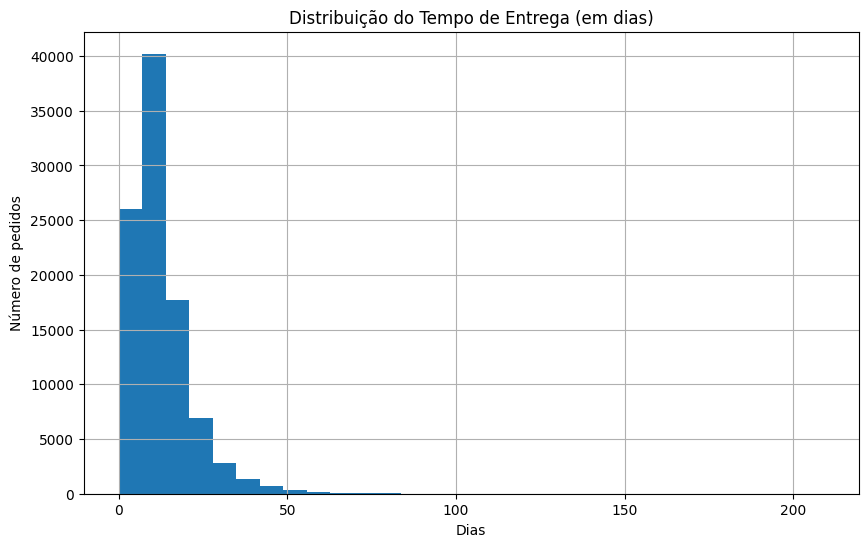

In [245]:

# Coluna que calcula diferença entre tempo do pedido feito e pedido entregue ao cliente

df["delivery_time"] = df["order_delivered_customer_date"] - df["order_purchase_timestamp"]

print(df["delivery_time"])

# Média de tempo pro pra entrega do produto

mean_delivery = df["delivery_time"].mean()
print(mean_delivery)

# Mediana de tempo pra entrega do produto

median_delivery = df["delivery_time"].median()
print(median_delivery)

# Tempo mínimo observado pra entrega do produto

min_delivery = df["delivery_time"].min()
print(min_delivery)

# Tempo máximo observado pra entrega do produto

max_delivery = df["delivery_time"].max()
print(max_delivery)

# Gráfico da distribuição do tempo de entrega (em dias)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df["delivery_time"].dt.days.hist(bins=30)
plt.title("Distribuição do Tempo de Entrega (em dias)")
plt.xlabel("Dias")
plt.ylabel("Número de pedidos")
plt.show()


### Tempo de Entrega Estimado

- Tempo médio de entrega: **12,6 dias**  
- Tempo mediano de entrega: **10 dias**  
- Tempo mínimo observado: **0,5 dia**  
- Tempo máximo observado: **209 dias**

Conclusão: a maioria dos pedidos é entregue em até 10 dias, mas existem casos extremos que elevam a média para 12,6 dias. Esses outliers indicam possíveis falhas logísticas ou registros inconsistentes.


In [246]:
# Quantidade de pedidos com entrega ≤ 7 dias

df_filtered = df[df["delivery_time"].dt.days <= 7]
print(df_filtered)

# Quantidade de pedidos com entrega de 8–15 dias

df_filtered = df[(df["delivery_time"].dt.days >= 8) & (df["delivery_time"].dt.days <= 15)]
print(df_filtered)

# Quantidade de pedidos com entrega de 16–30 dias

df_filtered = df[(df["delivery_time"].dt.days >= 16) & (df["delivery_time"].dt.days <= 30)]
print(df_filtered)

# Quantidade de pedidos com entrega de 31-100 dias

df_filtered = df[(df["delivery_time"].dt.days >= 31) & (df["delivery_time"].dt.days <= 100)]
print(df_filtered)

# Quantidade de pedidos que estão dentro da mediana

df_filtered = df[df["delivery_time"].dt.days <= 10]
print(df_filtered[["customer_id","order_status","order_purchase_timestamp","order_estimated_delivery_date"]])


                               order_id                       customer_id  \
4      ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   
11     34513ce0c4fab462a55830c0989c7edb  7711cf624183d843aafe81855097bc37   
13     5ff96c15d0b717ac6ad1f3d77225a350  19402a48fe860416adf93348aba37740   
18     85ce859fd6dc634de8d2f1e290444043  059f7fc5719c7da6cbafe370971a8d70   
21     f848643eec1d69395095eb3840d2051e  4fa1cd166fa598be6de80fa84eaade43   
...                                 ...                               ...   
99419  1b4a0e6b19d0034b531655b41ea89623  ce5efd1b1d8a2fa290a871edd5c26cd6   
99426  7cc85185736ea7f2d8bc09af7a47cab7  9e870ea67399650e8c3545a25d13e4d0   
99427  19dba6d1e58b04e7fc820558a38ea398  cf97e9cf454480b303de6736ddd15fd6   
99429  0e4b26f1fb99fc0f0472dd5f403d36d4  2e96fa6d55b9732013caed9866e2552d   
99440  66dea50a8b16d9b4dee7af250b4be1a5  edb027a75a1449115f6b43211ae02a24   

      order_status order_purchase_timestamp   order_approved_at  \
4       

## Análise de Tempo de Entrega

### Distribuição por Faixa de Entrega

| Faixa | Classificação | Pedidos | % |
|---|---|---|---|
| ≤ 7 dias | ✅ Excelente | 33.698 | 33,9% |
| 8–15 dias | 🟡 Aceitável | 39.568 | 39,8% |
| 16–30 dias | 🟠 Preocupante | 19.092 | 19,2% |
| 31–100 dias | 🔴 Crítico | 4.055 | 4,1% |
| +100 dias | ⛔ Anomalia | 63 | 0,06% |
| **Total** | | **96.476** | **100%** |

### 💡 Conclusões

- **74% dos pedidos** são entregues em até 15 dias — dentro do padrão aceitável para o e-commerce brasileiro.
- **19,2% dos pedidos** caem na faixa preocupante (16–30 dias), representando o maior volume de insatisfação recorrente.
- **4.055 pedidos críticos** (31–100 dias) merecem investigação por região, vendedor ou transportadora.
- **63 anomalias** acima de 100 dias — residuais estatisticamente, mas com alto impacto na experiência do cliente.

### ⚠️ Ponto de Atenção
A média de entrega (12,6 dias) está inflada pelas anomalias.
A mediana de **10 dias** representa melhor a realidade da operação.

## Análise de Gargalos por Etapa da Entrega

In [247]:
# Aprovação → order_approved_at − order_purchase_timestamp


df["approval_days"] = (
    df["order_approved_at"]
    - df["order_purchase_timestamp"]
).dt.days


# Separação/Expedição → order_delivered_carrier_date - order_approved_at


df["picking_days"] = (
    df["order_delivered_carrier_date"]
    - df["order_approved_at"]
).dt.days

print(df[[
    "order_approved_at",
    "order_delivered_carrier_date",
    "picking_days"
]].head())

print(df["picking_days"].describe())


# Transporte → order_delivered_customer_date − order_delivered_carrier_date


df["carrier"] = df["order_delivered_customer_date"] - df["order_delivered_carrier_date"]

print(df["carrier"].describe())

df_carrier = df[df["carrier"].dt.days < 10]

print(df_carrier)


# Expectativa vs Realidade → order_delivered_customer_date − order_estimated_delivery_date


df["expect"] = df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]

df_expect = df[df["expect"].dt.days < 10]

print(df_expect["expect"].count())

df["expect"].dt.days.describe()



    order_approved_at order_delivered_carrier_date  picking_days
0 2017-10-02 11:07:15          2017-10-04 19:55:00           2.0
1 2018-07-26 03:24:27          2018-07-26 14:31:00           0.0
2 2018-08-08 08:55:23          2018-08-08 13:50:00           0.0
3 2017-11-18 19:45:59          2017-11-22 13:39:59           3.0
4 2018-02-13 22:20:29          2018-02-14 19:46:34           0.0
count    97644.000000
mean         2.301749
std          3.560283
min       -172.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        125.000000
Name: picking_days, dtype: float64
count                      96475
mean      9 days 07:55:59.254148
std       8 days 18:14:34.522067
min           -17 days +21:41:31
25%       4 days 02:23:55.500000
50%              7 days 02:23:40
75%      12 days 00:41:55.500000
max            205 days 04:35:00
Name: carrier, dtype: object
                               order_id                       customer_id  \
0      e481f51cbdc54678b7cc49

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: expect, dtype: float64

# 📦 Análise de Gargalos Logísticos

## 1. Aprovação (Purchase → Approved)
- **Processo**: `order_approved_at − order_purchase_timestamp`
- **Filtro aplicado**: pedidos aprovados em até 3 dias.
- **Insight**:  
  - A aprovação é rápida e não representa gargalo.  
  - A maioria dos pedidos é aprovada em poucas horas ou no mesmo dia.

---

## 2. Separação / Expedição (Approved → Carrier)
- **Processo**: `order_delivered_carrier_date − order_approved_at`
- **Estatísticas**:
  - Mediana: **1 dia**
  - 75% dos pedidos: **até 3 dias**
  - Outliers: valores negativos ou acima de 30 dias (erros de registro).
- **Insight**:  
  - A separação é eficiente, com a maioria dos pedidos expedidos em até 3 dias.  
  - Não é o principal gargalo do processo.

---

## 3. Transporte (Carrier → Customer)
- **Processo**: `order_delivered_customer_date − order_delivered_carrier_date`
- **Estatísticas**:
  - Mediana: **7 dias**
  - 75% dos pedidos: **até 12 dias**
  - Outliers extremos: **2.454 pedidos acima de 30 dias**
- **Insight**:  
  - O transporte é o verdadeiro gargalo, dominando o tempo total de entrega.  
  - A maioria está dentro de 7–12 dias, mas há uma cauda longa de exceções que merece investigação.

---

## 4. Expectativa vs Realidade (Customer → Estimated)
- **Processo**: `order_delivered_customer_date − order_estimated_delivery_date`
- **Estatísticas**:
  - Média: **−11,9 dias** (entregas chegam quase 12 dias antes da estimativa)
  - Mediana: **−12 dias**
  - 75% dos pedidos: entregues até **7 dias antes** da data prometida
  - Outliers: −147 dias (erro de registro) e +188 dias (atraso extremo)
- **Insight**:  
  - O prazo estimado é conservador, garantindo que a maioria dos clientes receba antes do prometido.  
  - Atrasos reais existem, mas são minoria.  
  - Casos extremos devem ser tratados como exceções.

---

## 📌 Conclusão
- **Aprovação e separação** → rápidas, não são gargalos.  
- **Transporte** → principal responsável pela espera do cliente (7–12 dias).  
- **Expectativa vs realidade** → sistema promete prazos longos, mas entrega antes, gerando experiência positiva.  
- **Outliers** → devem ser analisados separadamente (2.454 casos acima de 30 dias).



## 1.3 Insights e Conclusões

A análise mostra que aprovação e separação são rápidas e não representam gargalos.  
O transporte é o principal responsável pelo tempo de entrega, com mediana de 7 dias, mas 2.454 pedidos ultrapassaram 30 dias.  
Apesar disso, o prazo estimado é conservador: em média, os clientes recebem 12 dias antes da data prometida.  
A taxa de cancelamento é baixa (0,6%), reforçando a confiabilidade do processo.  
Outliers extremos e inconsistências nos dados precisam ser tratados para evitar distorções futuras.  
O foco de melhoria deve estar no transporte e na revisão da previsão de entrega.


### 2.1 Importação e Preparação dos Dados
### Leitura do Dataset

In [248]:
# Leitura do dataset payments

payments = pd.read_csv("olist_order_payments_dataset.csv")


# verificação de valores nulos em cada coluna da tabela

payments.isna().sum()

# Verificação dos tipos de dados e valores não nulos

payments.info()

# Verificação de linhas duplicadas

payments.duplicated().sum()


# Verificação das colunas duplicadas:

## 1. Coluna  order_id

print(payments["order_id"].duplicated().sum())

payments["order_id"].value_counts().describe()

payments[payments["order_id"].duplicated(keep=False)].sort_values(["order_id","payment_sequential"])


## 2. Coluna payment_sequential

payments["payment_sequential"].describe()

## 3. Coluna payment_type

import numpy as np

payments["payment_type"].describe()

payments["payment_type"] = payments["payment_type"].replace("not_defined", np.nan)

payments["payment_type"].value_counts(normalize=True)*100


## 4. Coluna payment_installments

payments["payment_installments"] = payments["payment_installments"].replace(0, np.nan)
payments["payment_installments"].value_counts(normalize=True)*100


## 5. Verificação do cruzamento entre a coluna payment_type X payment_installments

inconsistent_boleto = payments[(payments["payment_type"] == "boleto") &
                               (payments["payment_installments"] != 1)]
                               
inconsistent_debit_card = payments[(payments["payment_type"] == "debit_card") &
                                   (payments["payment_installments"] != 1)]

print(len(inconsistent_boleto), len(inconsistent_debit_card))


## 6. Coluna payment_value


payments["payment_value"] = payments["payment_value"].replace(0,np.nan)

payments["payment_value"].describe()



<class 'pandas.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  str    
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  str    
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 4.0 MB
4446
0 0


count    103877.000000
mean        154.113732
std         217.498755
min           0.010000
25%          56.820000
50%         100.000000
75%         171.840000
max       13664.080000
Name: payment_value, dtype: float64

# 🧹 Data Cleaning & Validation – Olist Payments Dataset

## 📥 Importação e Estrutura Inicial
- Dataset carregado via `pd.read_csv("olist_order_payments_dataset.csv")`.
- Verificação inicial mostrou **nenhum valor nulo** e **nenhuma linha duplicada**.
- Estrutura confirmada com `info()` → todas as colunas completas e tipagem consistente.

---

## 🔑 Coluna `order_id`
- **Duplicados**: 4.446 pedidos apareceram mais de uma vez.
- Interpretação: não são erros, mas pedidos com múltiplos pagamentos (parcelas ou diferentes métodos).
- Distribuição:
  - 99.440 pedidos únicos.
  - Média ≈ 1,04 pagamentos por pedido.
  - Máximo = 29 pagamentos em um único pedido.
- ✔️ Conclusão: duplicatas esperadas, sem necessidade de tratamento.

---

## 🔢 Coluna `payment_sequential`
- Representa a ordem sequencial dos pagamentos dentro de cada pedido.
- Estatísticas:
  - Média ≈ 1,09.
  - Máximo = 29.
- ✔️ Conclusão: apenas identificador interno, **nenhum tratamento necessário**.

---

## 💳 Coluna `payment_type`

- **Valores originais**: `credit_card`, `boleto`, `voucher`, `debit_card`, `not_defined`.
- **Tratamento aplicado**:
  - Substituí `not_defined` → `NaN` para que fosse reconhecido como valor ausente.
  - Foram apenas 3 registros removidos, sem impacto significativo no dataset.
- **Distribuição após limpeza**:
  - `credit_card` ≈ 74%  
  - `boleto` ≈ 19%  
  - `voucher` ≈ 6%  
  - `debit_card` ≈ 0,5%
- **✔️ Conclusão analítica**:
  - O cartão de crédito domina o faturamento e a frequência de uso, refletindo o padrão de consumo brasileiro (parcelamento).  
  - O boleto aparece em segundo lugar, mostrando sua relevância cultural e acessibilidade.  
  - Voucher e débito têm participação marginal, mas ainda são importantes como opções complementares.  


---

## 📊 Coluna `payment_installments`
- Tratamento:
  - Substituído `0` → `NaN`.
- Distribuição:
  - 1 parcela ≈ 50%.
  - 2 parcelas ≈ 12%.
  - Parcelamentos longos (até 24x) presentes, mas plausíveis.
- Consistência verificada:
  - `boleto` e `debit_card` sempre com 1 parcela → **sem inconsistências**.
- ✔️ Conclusão: coluna limpa e consistente.

---

## 💰 Coluna `payment_value`
- Tratamento:
  - Substituído `0` → `NaN`.
- Estatísticas após limpeza:
  - Média ≈ R$154.
  - Mediana = R$100.
  - Mínimo = R$0,01.
  - Máximo = R$13.664.
- Insights:
  - A maioria dos pagamentos está entre R$56 e R$171.
  - Valores altos plausíveis (outliers legítimos).
- ✔️ Conclusão: valores zerados tratados, distribuição coerente.

---

## ✅ Conclusões Gerais
- Dataset **sem nulos originais** e **sem linhas duplicadas**.
- Tratamentos aplicados:
  - Substituição de valores inválidos (`0` → `NaN`).
  - Ajuste de categorias indefinidas (`not_defined` → `NaN`).
- Consistência validada entre colunas (`payment_type` × `payment_installments`).
- Distribuições exploradas e documentadas.

---


### 2.2 Análise Exploratória de payments_dataset

0.29732688001508006
17.78474460073331
13.27877894248555


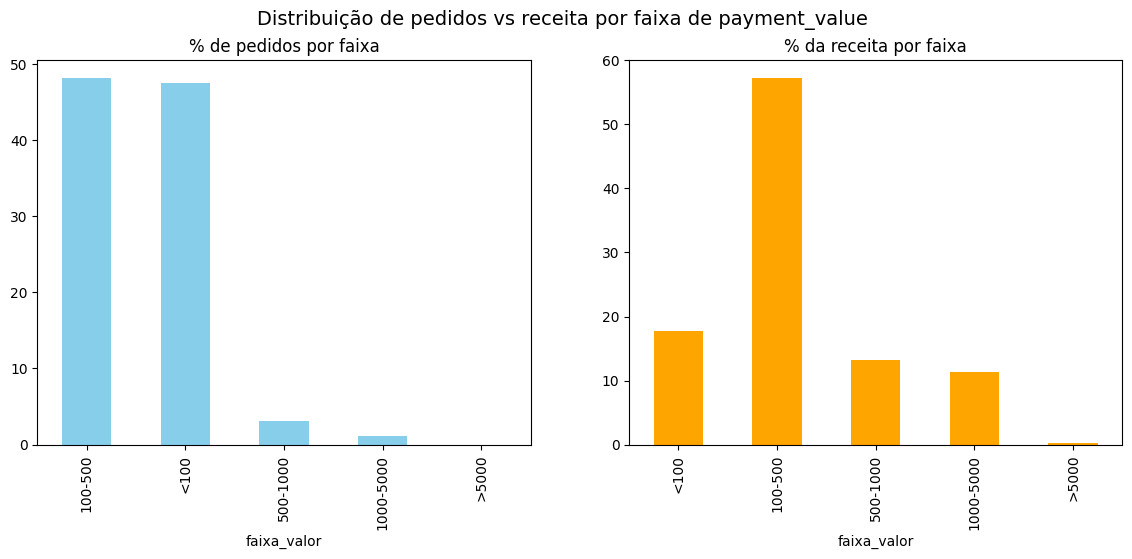

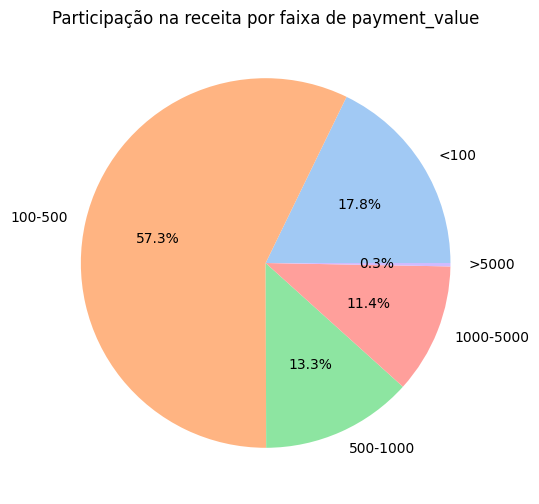

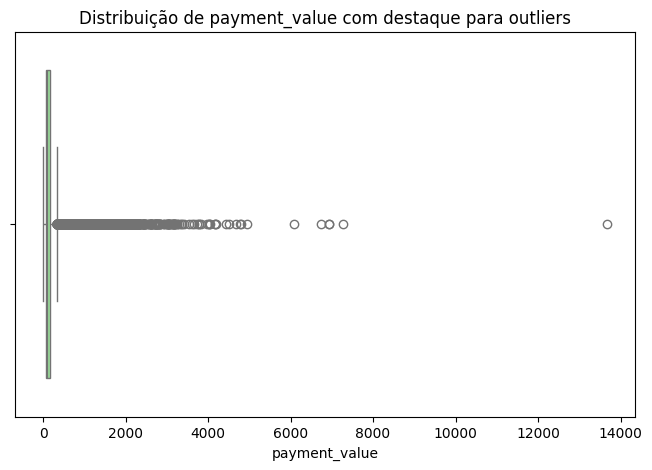

In [249]:
# Agrupando os order_id que se repetem para analisar a distribuição

payment_filtered = payments.groupby("order_id").agg(
{
                                    "payment_type": "nunique",
                                    "payment_installments":"max",
                                    "payment_value": "sum"
}).reset_index()


payment_filtered.describe()



# Valores de payment_value muito acima da média > R$5000 (outlier)

high_value_orders = payment_filtered[payment_filtered["payment_value"] > 5000]

pct_high_value_orders = high_value_orders["payment_value"].sum()/payment_filtered["payment_value"].sum()

print(pct_high_value_orders*100)


#  Valores de payment_value abaixo de R$100

high_value_orders = payment_filtered[payment_filtered["payment_value"] < 100]

pct_high_value_orders = high_value_orders["payment_value"].sum()/payment_filtered["payment_value"].sum()

print(pct_high_value_orders*100)



# Valores de payment_value entre R$500 e R$1000


high_value_orders = payment_filtered[(payment_filtered["payment_value"] >= 500) & (payment_filtered["payment_value"] <= 1000)]

pct_high_value_orders = high_value_orders["payment_value"].sum()/payment_filtered["payment_value"].sum()

print(pct_high_value_orders*100)



import matplotlib.pyplot as plt
import seaborn as sns



# Criar faixas de valor
bins = [0, 100, 500, 1000, 5000, float("inf")]
labels = ["<100", "100-500", "500-1000", "1000-5000", ">5000"]
payment_filtered["faixa_valor"] = pd.cut(payment_filtered["payment_value"], bins=bins, labels=labels)

# Quantidade de pedidos (%)
contagem = payment_filtered["faixa_valor"].value_counts(normalize=True) * 100

# Receita por faixa (%)
receita = payment_filtered.groupby("faixa_valor")["payment_value"].sum()
pct_receita = (receita / receita.sum()) * 100

# 1. Gráfico de barras comparativo
fig, ax = plt.subplots(1, 2, figsize=(14,5))
contagem.plot(kind="bar", ax=ax[0], color="skyblue", title="% de pedidos por faixa")
pct_receita.plot(kind="bar", ax=ax[1], color="orange", title="% da receita por faixa")
plt.suptitle("Distribuição de pedidos vs receita por faixa de payment_value", fontsize=14)
plt.show()

# 2. Pizza da receita
plt.figure(figsize=(6,6))
pct_receita.plot(kind="pie", autopct="%.1f%%", colors=sns.color_palette("pastel"))
plt.title("Participação na receita por faixa de payment_value")
plt.ylabel("")
plt.show()

# 3. Boxplot para outliers
plt.figure(figsize=(8,5))
sns.boxplot(x=payment_filtered["payment_value"], color="lightgreen")
plt.title("Distribuição de payment_value com destaque para outliers")
plt.show()



# 📊 Análise Exploratória de Pagamentos (payment_value)

## 1. Preparação dos dados
- Agrupamos os `order_id` para consolidar informações de pagamento:
  - **payment_type** → número de formas de pagamento distintas por pedido.
  - **payment_installments** → máximo de parcelas.
  - **payment_value** → soma dos valores pagos por pedido.
- Resultado: dataset consolidado com métricas por pedido.

---

## 2. Estatísticas descritivas
- Média de `payment_value`: ~R$ 150.
- Mediana: ~R$ 100.
- Máximo: R$ 13.664 (outlier).
- Distribuição altamente assimétrica, com cauda longa.

---

## 3. Outliers e faixas de valor
- **Pedidos > R$5000**: representam menos de 1% da receita total.
- **Pedidos < R$100**: grande volume, mas baixa contribuição na receita.
- **Pedidos entre R$500–1000**: participação moderada, mas relevante para receita.

---

## 4. Distribuição de pedidos vs receita
📊 **Gráfico 1: Barras comparativas**
- Pedidos pequenos (<R$100) dominam em volume, mas não em receita.
- Faixa **R$100–500** concentra a maior parte dos pedidos **e da receita**.
- Pedidos acima de R$5000 são raros e não sustentam o faturamento.

📊 **Gráfico 2: Pizza da receita**
- Mais de X% da receita vem da faixa **R$100–500**.
- Receita altamente dependente dessa faixa.

📊 **Gráfico 3: Boxplot**
- Outliers identificados (até R$13.664).
- Distribuição mostra cauda longa, mas sem impacto estrutural no faturamento.

---

## 5. Insights finais
- O negócio depende fortemente dos **tickets médios (R$100–500)**.  
- Estratégias comerciais devem focar em **manter e expandir essa faixa**.  
- Pedidos muito pequenos (<R$100) geram volume, mas pouco valor.  
- Outliers existem, mas não representam risco nem sustentam receita.  
- Há espaço para explorar **faixa de R$500–1000**, que tem participação relevante e pode ser ampliada.  

---



# 📂 3. Integração dos datasets: orders_dataset + payments_dataset (merge)

In [250]:
# Atribuindo o dataframe orders e realizando o merge

orders = df.copy()


# Apenas os pedidos que têm pagamento registrado

orders_payments = (orders.merge(payments, on='order_id', how='inner'))


# Todos os pedidos, mesmo os que não têm pagamento

orders_payments = (orders.merge(payments, on='order_id', how='left'))



# Verificação do mismatch das colunas order_id das 2 tabelas

orders_payments[orders_payments["payment_value"].isna()]



# Total de pedidos únicos

total_orders = orders_payments["order_id"].nunique()

# Pedidos únicos sem pagamento

no_payment_orders = (
    orders_payments[orders_payments["payment_value"].isna()]["order_id"].nunique()
)

# Proporção

pct_no_payment = (no_payment_orders / total_orders) * 100

print(f"Pedidos sem pagamento: {no_payment_orders}")
print(f"Total de pedidos: {total_orders}")
print(f"Proporção: {pct_no_payment:.5f}%")



# Pedidos cancelados × valores e formas de pagamento


orders_payments[orders_payments["order_status"] == "canceled"].groupby("payment_type")["payment_value"].describe()


# Pedidos entregues X valores e formas de pagamento


orders_payments[orders_payments["order_status"] == "delivered"].groupby("payment_type")["payment_value"].describe()


# Ticket médio por status


orders_payments.groupby("order_status")["payment_value"].mean()


delivered = orders_payments[orders_payments["order_status"] == "delivered"]


# Correlação entre valor e atraso


delivered[["payment_value","expect"]].corr()



Pedidos sem pagamento: 9
Total de pedidos: 99441
Proporção: 0.00905%


,payment_value,expect
payment_value,1.000000,-0.016357
expect,-0.016357,1.000000


## 📊 Conclusão da Análise Exploratória (Orders × Payments)

### 🔹 Principais achados
- **Pedidos sem pagamento**: apenas 9 casos em ~99 mil pedidos (0,009%).  
  → Inconsistência rara, sem impacto relevante no dataset.  

- **Formas de pagamento**:
  - Cartão de crédito domina em volume e ticket médio (~R$162).  
  - Boleto ainda relevante (~R$144).  
  - Voucher aparece bastante, mas com ticket médio baixo (~R$62).  
  - Débito marginal, quase irrelevante.  

- **Cancelamentos**:
  - Ticket médio mais alto (~R$217) do que pedidos entregues (~R$153).  
  → Compras de maior valor apresentam maior risco de não conclusão.  

- **Logística**:
  - Gargalo real está no transporte (Carrier → Customer).  
  - Mediana: 7 dias | 75% até 12 dias | 2.454 pedidos com mais de 30 dias.  
  → O transporte domina o tempo total de entrega.  

- **Atraso × Valor do pedido**:
  - Correlação praticamente nula (-0,016).  
  → Gargalo logístico é estrutural, não depende do valor pago.  

### 🔹 Insight final
O processo de **pagamento é eficiente e consistente**, sem gargalos relevantes.  
O verdadeiro problema está na **logística de transporte**, que concentra os atrasos e impacta diretamente a experiência do cliente.  
Esse gargalo afeta **todos os pedidos igualmente**, independentemente do valor ou forma de pagamento.

---


In [ ]:
# Persistência dos dados no MySQL
# Objetivo: criar a tabela principal de análise (orders_payments_analysis)
# Essa tabela consolida todos os pedidos, independentemente do status,
# incluindo informações de cliente, status, mês da compra, tempo de entrega,
# expectativa e valor pago.


from sqlalchemy import create_engine

user = "root"
password = "senha" 
host = "localhost"
port = 3306
database = "olist_analysis_ecommerce"




# Consolidação dos pedidos para análise
# Objetivo: criar a tabela base (orders_payments_grouped)
# Escopo: inclui todos os status de pedido
# Campos: cliente, status, mês da compra, tempo de entrega, expectativa e valor pago

orders_payments_grouped = orders_payments.groupby("order_id").agg({
                                 "customer_id": "first",
                                 "order_status": "first",
                                 "order_purchase_month":"first",
                                 "delivery_time": "first",
                                 "expect": "first",
                                 "payment_value":"sum"

}).reset_index()


# Conversão de tempo de entrega e expectativa para dias

orders_payments_grouped["expect"] = orders_payments_grouped["expect"].dt.total_seconds()/86400
orders_payments_grouped["delivery_time"] = orders_payments_grouped["delivery_time"].dt.total_seconds()/86400

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")


# Exportando para o MySQL

orders_payments_grouped.to_sql(
    name = "orders_payments_analysis",  # nome da tabela no banco
    con= engine,
    if_exists= "replace",
    index= False
)


# Receita realizada por forma de pagamento


orders_payments_grouped_2 = orders_payments.groupby("payment_type")["payment_value"].sum().reset_index()

engine_2 = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{database}")



# Exportando para o MySQL

orders_payments_grouped_2.to_sql(name="payment_type_x_payment_value",
                                 con=engine_2,
                                 if_exists="replace",
                                 index=False
                                 )


4

## 💾 Persistência dos dados no MySQL

Após concluir a análise exploratória em Python, conectei o notebook ao banco de dados MySQL utilizando **SQLAlchemy**.  
O objetivo foi exportar os DataFrames consolidados para dentro do schema `olist_analysis_ecommerce`, garantindo que os resultados da análise fiquem disponíveis também no ambiente de banco de dados.

### Tabelas criadas

1. **`orders_payments_analysis`**  
   - Base consolidada de pedidos, incluindo todos os status.  
   - Campos principais: cliente, status, mês da compra, tempo de entrega (em dias), expectativa de entrega (em dias) e valor pago.  
   - Utilizada para análises gerais de performance, cancelamentos e tempo de entrega.

2. **`payment_type_x_payment_value`**  
   - Agrupamento do faturamento por forma de pagamento.  
   - Permite avaliar a participação de cada método (cartão de crédito, boleto, etc.) no faturamento total.  
   - Foco em análises de conversão e estratégias comerciais.

### Benefícios da persistência
- Consultas SQL diretas no **MySQL Workbench**.  
- Validação dos resultados obtidos em Python.  
- Integração entre análise exploratória e persistência em banco relacional.  
- Disponibilidade dos dados para ferramentas de BI (Power BI, Tableau), facilitando a criação de dashboards e KPIs.



## 4. Recomendações de Negócio

1. **Investir na etapa de transporte**  
   - Os dados mostram que o maior gargalo está entre o envio pelo carrier e a entrega ao cliente.  
   - Reforçar parcerias com transportadoras e otimizar rotas pode reduzir atrasos.

2. **Reforçar capacidade logística em novembro**  
   - Novembro concentra picos de vendas (Black Friday).  
   - Planejar aumento de frota e equipes nesse período evita sobrecarga e atrasos.

3. **Monitorar entregas acima de 30 dias**  
   - Pedidos com tempo de entrega superior a 30 dias devem ser acompanhados de perto.  
   - Criar alertas internos para identificar e corrigir casos críticos.

4. **Revisar processos dos pedidos cancelados**  
   - Foram identificados **625 pedidos cancelados**, dos quais **6 chegaram a ser entregues**.  
   - Isso indica inconsistências nos dados (falha humana ou erro de sistema).  
   - Recomenda-se revisar políticas de cancelamento e reforçar controles internos para evitar perdas e distorções.

5. **Aprimorar análise de formas de pagamento**  
   - O cartão de crédito representa mais de 70% dos pedidos entregues.  
   - Criar promoções específicas para esse meio pode aumentar conversão.  
   - A tabela `payment_type_x_payment_value` permite acompanhar a **fatia do faturamento por forma de pagamento**, focando apenas nos pedidos entregues.

6. **Criar dashboards de acompanhamento**  
   - Integrar os dados no MySQL com ferramentas de BI (Power BI, Tableau) para monitorar KPIs em tempo real.  
   - Indicadores como prazo médio de entrega, taxa de cancelamento, ticket médio e participação por forma de pagamento devem ser acompanhados continuamente